# Z-Score Detector

Statistics-based detector — no training in the ML sense, just a threshold.
Uses the z_score feature already computed per metric in data_prep.py.


In [11]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

ML_DIR = Path("../ml_models")

In [12]:
X_train = np.load(ML_DIR / "X_train.npy")
X_test  = np.load(ML_DIR / "X_test.npy")
y_train = np.load(ML_DIR / "y_train.npy")
y_test  = np.load(ML_DIR / "y_test.npy")

with open(ML_DIR / "feature_cols.json") as f:
    feature_cols = json.load(f)

with open(ML_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Loaded:", X_train.shape, X_test.shape)

Loaded: (12776, 28) (3195, 28)


/Users/esanduepa/Library/Python/3.13/lib/python/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Why we need to undo the scaling first

data_prep.py used StandardScaler to rescale all 28 features — including
the z_score columns themselves — to mean 0, std 1. That was the right
move for Isolation Forest and the LSTM.

But for THIS detector, we need the ORIGINAL z-score numbers — the literal
"how many standard deviations away from normal" — because a threshold
like "3.0" only means something on the real z-score, not a rescaled
version of it.

Good news: scaling is reversible. The scaler remembers exactly what mean
and std it used, so we can perfectly undo it — no need to redo data_prep.

In [14]:
X_train_raw = scaler.inverse_transform(X_train)
X_test_raw  = scaler.inverse_transform(X_test)

z_idx_example = feature_cols.index("cpu_usage_z_score")
print("cpu_usage_z_score sample values:", X_train_raw[:5, z_idx_example])

cpu_usage_z_score sample values: [0. 0. 0. 0. 0.]


In [15]:
z_score_cols = [c for c in feature_cols if c.endswith("_z_score")]
z_score_idx  = [feature_cols.index(c) for c in z_score_cols]

print(f"{len(z_score_cols)} z-score columns:")
for c in z_score_cols:
    print(" ", c)

Z_train = X_train_raw[:, z_score_idx]   # shape (n_rows, 7)
Z_test  = X_test_raw[:, z_score_idx]

7 z-score columns:
  cpu_usage_z_score
  memory_usage_z_score
  request_latency_ms_z_score
  requests_per_sec_z_score
  error_rate_z_score
  db_connections_z_score
  disk_usage_z_score


In [10]:
print("Z_train stats (raw z-scores, all 7 metrics combined):")
print("  min:   ", Z_train.min())
print("  max:   ", Z_train.max())
print("  mean:  ", Z_train.mean())
print("  median of |z|:", np.median(np.abs(Z_train)))

max_abs_z = np.abs(Z_train).max(axis=1)
print("\nWorst-metric-per-row (max_abs_z) stats:")
print("  min: ", max_abs_z.min())
print("  max: ", max_abs_z.max())
print("  mean:", max_abs_z.mean())
print(f"  % of rows above 5.75: {100 * (max_abs_z > 5.75).mean():.1f}%")

# which metric is usually the "worst offender"?
worst_metric_idx = np.abs(Z_train).argmax(axis=1)
import collections
counts = collections.Counter(worst_metric_idx)
print("\nWhich metric is most often the extreme one:")
for idx, count in counts.most_common():
    print(f"  {z_score_cols[idx]:<28} worst in {count} rows ({100*count/len(worst_metric_idx):.1f}%)")

Z_train stats (raw z-scores, all 7 metrics combined):
  min:    -5.0728546e+15
  max:    8.6069427e+14
  mean:   -3.1428622e+10
  median of |z|: 2048.0

Worst-metric-per-row (max_abs_z) stats:
  min:  32768.0
  max:  5.0728546e+15
  mean: 7.116213e+11
  % of rows above 5.75: 100.0%

Which metric is most often the extreme one:
  error_rate_z_score           worst in 12766 rows (99.9%)
  memory_usage_z_score         worst in 4 rows (0.0%)
  request_latency_ms_z_score   worst in 3 rows (0.0%)
  requests_per_sec_z_score     worst in 1 rows (0.0%)
  disk_usage_z_score           worst in 1 rows (0.0%)
  cpu_usage_z_score            worst in 1 rows (0.0%)


## The detection rule

For each reading, look at all 7 metrics' z-scores. If ANY single metric
strays more than `threshold` standard deviations from its recent normal,
flag the whole reading as anomalous.

We use whichever metric has the LARGEST absolute z-score — one badly
behaving metric (e.g. cpu spiking) is enough to call the whole reading
suspicious. We don't need every metric to look unusual at once.

In [16]:
def zscore_predict(Z: np.ndarray, threshold: float) -> np.ndarray:
    """Flag as anomaly if ANY metric's |z-score| exceeds threshold."""
    max_abs_z = np.abs(Z).max(axis=1)
    return (max_abs_z > threshold).astype(int)

y_pred_train = zscore_predict(Z_train, threshold=3.0)

print(f"Threshold = 3.0")
print(f"Precision: {precision_score(y_train, y_pred_train):.3f}")
print(f"Recall:    {recall_score(y_train, y_pred_train):.3f}")
print(f"F1 score:  {f1_score(y_train, y_pred_train):.3f}")

Threshold = 3.0
Precision: 0.255
Recall:    0.212
F1 score:  0.231


## Precision vs recall — why one fixed threshold isn't automatically right

Precision: of everything we flagged, how much was really anomalous?
Low precision = lots of false alarms.

Recall: of all the real anomalies, how many did we actually catch?
Low recall = we missed real incidents.

A very LOW threshold flags almost everything — recall goes up, precision
crashes. A very HIGH threshold flags almost nothing — precision goes up,
recall crashes. We'll test a range of thresholds and pick the one with
the best balance (F1 score).

In [17]:
thresholds = np.arange(1.0, 6.0, 0.25)
results = []

for t in thresholds:
    y_pred = zscore_predict(Z_train, threshold=t)
    results.append({
        "threshold": t,
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall":    recall_score(y_train, y_pred, zero_division=0),
        "f1":        f1_score(y_train, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1
0,1.00,0.186504,0.899602,0.308955
1,1.25,0.188331,0.846215,0.308094
2,1.50,0.193317,0.772112,0.309214
3,1.75,0.200143,0.668127,0.308017
4,2.00,0.204118,0.549004,0.297592
5,2.25,0.214425,0.438247,0.287958
6,2.50,0.219154,0.344622,0.267926
7,2.75,0.235833,0.276892,0.254719
8,3.00,0.254545,0.211952,0.231304
9,3.25,0.273651,0.171713,0.211016


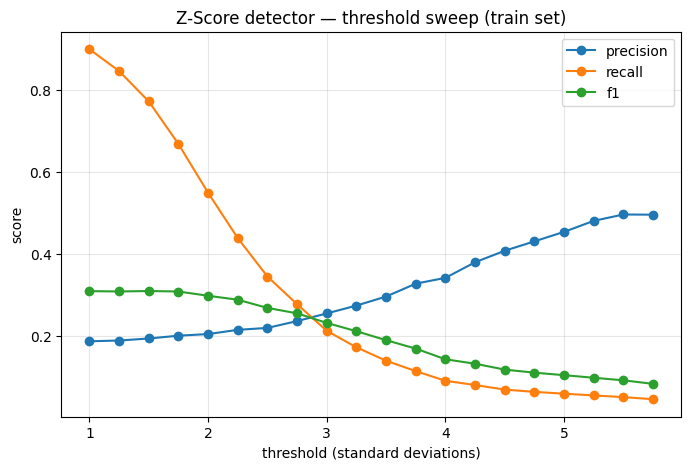

Best threshold: 1.5  (F1=0.309)


In [18]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="precision", marker="o")
plt.plot(results_df["threshold"], results_df["recall"],    label="recall",    marker="o")
plt.plot(results_df["threshold"], results_df["f1"],        label="f1",       marker="o")
plt.xlabel("threshold (standard deviations)")
plt.ylabel("score")
plt.title("Z-Score detector — threshold sweep (train set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_row = results_df.loc[results_df["f1"].idxmax()]
print(f"Best threshold: {best_row['threshold']}  (F1={best_row['f1']:.3f})")

## Final check — evaluate on the TEST set

We picked the threshold using only training data. Now we check it on data
it has never influenced at all — the honest, unbiased measurement of how
this detector will do in the real world.

In [19]:
best_threshold = float(best_row["threshold"])
y_pred_test = zscore_predict(Z_test, threshold=best_threshold)

print(f"Test set results (threshold={best_threshold}):")
print(f"  Precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.3f}")
print(f"  F1 score:  {f1_score(y_test, y_pred_test):.3f}")

Test set results (threshold=1.5):
  Precision: 0.254
  Recall:    0.802
  F1 score:  0.385


In [20]:
config = {
    "detector": "zscore",
    "threshold": best_threshold,
    "trained_on": "X_train.npy (data_prep.py output)",
}

with open(ML_DIR / "zscore_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:", config)

Saved: {'detector': 'zscore', 'threshold': 1.5, 'trained_on': 'X_train.npy (data_prep.py output)'}
